# Chapter 07. 공변량을 활용한 RCT 분석 — 선형 회귀

## 학습 목표

- RCT에서 공변량 조정이 정밀도를 향상시키는 이유를 이해한다
- OLS 회귀식을 이용하여 인과 효과를 추정한다
- 교호작용 항(Interaction Terms)으로 이질적 처치 효과를 분석한다
- 회귀 진단(Regression Diagnostics) — Jarque-Bera, Breusch-Pagan, VIF — 을 수행한다
- LLM의 Structured Outputs로 교호작용 항을 자동 식별한다
- CAIS linear_regression/estimator.py 코드와 우리 구현을 비교한다

## 환경 설정

이 노트북은 OpenAI API를 사용하여 LLM 기반 분석을 수행한다. 다음을 준비한다:
- `OPENAI_API_KEY` 환경 변수
- `statsmodels` (OLS 회귀), `scipy` (VIF 계산), `pandas`, `numpy`, `matplotlib`, `seaborn`

In [22]:
# 핵심 라이브러리 임포트
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# 통계 및 OLS 회귀
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [23]:
# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# Seaborn 스타일 설정
sns.set_theme(style="darkgrid")


In [24]:
# OpenAI SDK
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List, Optional

# 환경 변수 로드
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

## 1. RCT에서 공변량 조정의 역할

RCT에서 무작위배정이 이루어지면 처치와 공변량은 독립이므로, 원칙적으로 공변량 조정이 필요 없다.
그러나 **공변량 조정은 추정의 정밀도(precision)를 향상**시킨다:

$$\text{SE}(\hat{\tau}_{adjusted}) < \text{SE}(\hat{\tau}_{unadjusted})$$

이는 잔차 분산 감소 때문이다 (Lin, 2013).

In [25]:
# 시뮬레이션: 공변량 조정으로 정밀도 향상 증명

np.random.seed(42)

# RCT 데이터 생성 (n=500)
n = 500

# 공변량 X: 정규분포
X = np.random.normal(loc=50, scale=10, size=n)

# 무작위배정: 처치 D
D = np.random.binomial(n=1, p=0.5, size=n)

# 결과 Y = α + τD + βX + ε
# 진정한 효과: τ = 5, β = 0.8
alpha = 10
tau_true = 5
beta_true = 0.8
epsilon = np.random.normal(loc=0, scale=5, size=n)

Y = alpha + tau_true * D + beta_true * X + epsilon

# 데이터프레임
df_sim = pd.DataFrame({
    'Y': Y,
    'D': D,
    'X': X
})

print(f"데이터 생성 완료: n={n}")
print(df_sim.head())
print(f"\n결과 Y의 기술통계:")
print(df_sim['Y'].describe())

데이터 생성 완료: n=500
           Y  D          X
0  58.138123  1  54.967142
1  54.627454  1  48.617357
2  61.214053  0  56.476885
3  63.099560  1  65.230299
4  54.970140  1  47.658466

결과 Y의 기술통계:
count    500.000000
mean      52.902017
std        9.606324
min       26.052751
25%       46.436727
50%       53.316032
75%       58.974954
max       86.986898
Name: Y, dtype: float64


In [26]:
# 모델 1: 공변량 없이 (Unadjusted)

model_unadjusted = smf.ols('Y ~ D', data=df_sim)
results_unadjusted = model_unadjusted.fit()

tau_hat_unadjusted = results_unadjusted.params['D']
se_unadjusted = results_unadjusted.bse['D']

print("="*60)
print("[모델 1] 공변량 조정 없음 (Unadjusted)")
print("="*60)
print(f"회귀식: Y ~ D")
print(f"\n처치 효과 추정치: tau_hat = {tau_hat_unadjusted:.4f}")
print(f"표준오차: SE = {se_unadjusted:.4f}")
print(f"95% 신뢰구간: [{tau_hat_unadjusted - 1.96*se_unadjusted:.4f}, {tau_hat_unadjusted + 1.96*se_unadjusted:.4f}]")
print(f"\nR² = {results_unadjusted.rsquared:.4f}")

[모델 1] 공변량 조정 없음 (Unadjusted)
회귀식: Y ~ D

처치 효과 추정치: tau_hat = 4.6326
표준오차: SE = 0.8347
95% 신뢰구간: [2.9967, 6.2686]

R² = 0.0583


In [27]:
# 모델 2: 공변량 포함 (Adjusted)

model_adjusted = smf.ols('Y ~ D + X', data=df_sim)
results_adjusted = model_adjusted.fit()

tau_hat_adjusted = results_adjusted.params['D']
se_adjusted = results_adjusted.bse['D']

print("="*60)
print("[모델 2] 공변량 조정 (Adjusted)")
print("="*60)
print(f"회귀식: Y ~ D + X")
print(f"\n처치 효과 추정치: tau_hat = {tau_hat_adjusted:.4f}")
print(f"표준오차: SE = {se_adjusted:.4f}")
print(f"95% 신뢰구간: [{tau_hat_adjusted - 1.96*se_adjusted:.4f}, {tau_hat_adjusted + 1.96*se_adjusted:.4f}]")
print(f"\nR² = {results_adjusted.rsquared:.4f}")

[모델 2] 공변량 조정 (Adjusted)
회귀식: Y ~ D + X

처치 효과 추정치: tau_hat = 5.0979
표준오차: SE = 0.4473
95% 신뢰구간: [4.2212, 5.9745]

R² = 0.7303


In [28]:
# 정밀도 비교

se_reduction = (se_unadjusted - se_adjusted) / se_unadjusted * 100

print("="*60)
print("정밀도 향상 분석")
print("="*60)
print(f"\nUnadjusted SE: {se_unadjusted:.4f}")
print(f"Adjusted SE:   {se_adjusted:.4f}")
print(f"감소율:        {se_reduction:.2f}%")
print(f"\n신뢰 구간 폭:")
print(f"  Unadjusted: {2 * 1.96 * se_unadjusted:.4f}")
print(f"  Adjusted:   {2 * 1.96 * se_adjusted:.4f}")
print(f"\n결론: 공변량 조정으로 표준오차가 {se_reduction:.1f}% 감소했다.")
print(f"      이는 더 좁은 신뢰구간과 더 큰 검정력을 의미한다.")

정밀도 향상 분석

Unadjusted SE: 0.8347
Adjusted SE:   0.4473
감소율:        46.41%

신뢰 구간 폭:
  Unadjusted: 3.2719
  Adjusted:   1.7533

결론: 공변량 조정으로 표준오차가 46.4% 감소했다.
      이는 더 좁은 신뢰구간과 더 큰 검정력을 의미한다.


## 2. OLS를 이용한 인과 효과 추정

선형 회귀 모델:
$$Y_i = \alpha + \tau D_i + \beta X_i + \varepsilon_i$$

**인과적 해석**:
- RCT에서 $E[\varepsilon_i | D_i] = 0$ 이므로, $\hat{\tau}$는 **인과 효과**(Average Treatment Effect, ATE)이다.
- $\hat{\beta}$는 공변량 $X_i$와 결과 $Y_i$의 관계를 나타낸다.

In [29]:
# 실제 데이터: online_classroom.csv

data_path = './dataset/online_classroom.csv'

df_oc = pd.read_csv(data_path)

print("online_classroom.csv 로드 완료")
print(f"데이터 크기: {df_oc.shape}")
print(f"\n컬럼: {list(df_oc.columns)}")
print(f"\n처음 5행:")
print(df_oc.head())

online_classroom.csv 로드 완료
데이터 크기: (323, 10)

컬럼: ['gender', 'asian', 'black', 'hawaiian', 'hispanic', 'unknown', 'white', 'format_ol', 'format_blended', 'falsexam']

처음 5행:
   gender  asian  black  hawaiian  hispanic  unknown  white  format_ol  \
0       0    0.0    0.0       0.0       0.0      0.0    1.0          0   
1       1    0.0    0.0       0.0       0.0      0.0    1.0          0   
2       1    0.0    0.0       0.0       0.0      0.0    1.0          0   
3       1    0.0    0.0       0.0       0.0      0.0    1.0          0   
4       1    0.0    0.0       0.0       0.0      0.0    1.0          1   

   format_blended  falsexam  
0             0.0  63.29997  
1             0.0  79.96000  
2             1.0  83.37000  
3             1.0  90.01994  
4             0.0  83.30000  


In [30]:
# 탐색적 데이터 분석 (EDA)

df_oc.describe()

,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
count,323.000000,247.000000,247.000000,247.000000,247.000000,247.000000,247.000000,323.000000,323.000000,323.000000
mean,0.578947,0.214575,0.068826,0.012146,0.016194,0.004049,0.684211,0.291022,0.337461,76.627336
std,0.494494,0.411361,0.253672,0.109759,0.126479,0.063628,0.465773,0.454938,0.473577,11.665256
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.015000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,78.330000
75%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,84.990000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,96.680000


Missing Values


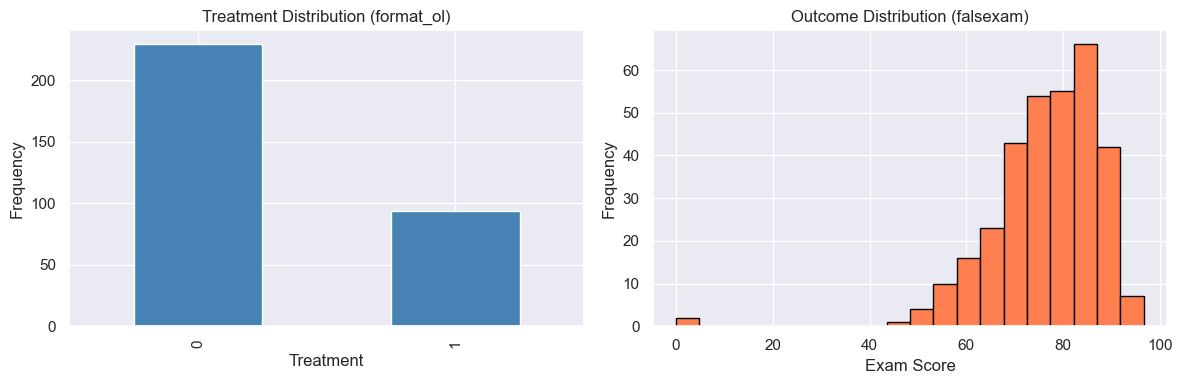

Treatment variable (format_ol) distribution:
format_ol
0    229
1     94
Name: count, dtype: int64


In [34]:
print("Missing Values")
df_oc.isnull().sum()

# Treatment & outcome distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_oc['format_ol'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Treatment Distribution (format_ol)')
axes[0].set_xlabel('Treatment')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_oc['falsexam'], bins=20, color='coral', edgecolor='black')
axes[1].set_title('Outcome Distribution (falsexam)')
axes[1].set_xlabel('Exam Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Treatment variable (format_ol) distribution:")
print(df_oc['format_ol'].value_counts())

In [35]:
df_oc.head()

,gender,asian,black,hawaiian,hispanic,unknown,white,format_ol,format_blended,falsexam
0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,63.29997
1,1,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,79.96000
2,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,83.37000
3,1,0.0,0.0,0.0,0.0,0.0,1.0,0,1.0,90.01994
4,1,0.0,0.0,0.0,0.0,0.0,1.0,1,0.0,83.30000


In [36]:
# OLS 회귀: 공변량 없음 vs 공변량 포함
# online_classroom.csv 컬럼: gender, asian, black, hawaiian,
# hispanic, unknown, white, format_ol, format_blended, falsexam
# → age, prior_gpa는 존재하지 않으므로 인종 더미변수를 공변량으로 사용한다.

df_clean = df_oc.dropna(subset=['format_ol', 'falsexam', 'gender', 'asian', 'black'])

print(f"분석 샘플 크기: {len(df_clean)}")

# 모델 1: 공변량 없음
model1 = smf.ols('falsexam ~ C(format_ol)', data=df_clean)
results1 = model1.fit()

# 모델 2: 성별 공변량 포함
model2 = smf.ols('falsexam ~ C(format_ol) + gender', data=df_clean)
results2 = model2.fit()

# 모델 3: 성별 + 인종 공변량 포함
model3 = smf.ols('falsexam ~ C(format_ol) + gender + asian + black + hispanic', data=df_clean)
results3 = model3.fit()

print("\n" + "="*70)
print("[모델 1] 공변량 없음: falsexam ~ format_ol")
print("="*70)
print(results1.summary())

print("\n" + "="*70)
print("[모델 2] 공변량 포함: falsexam ~ format_ol + gender")
print("="*70)
print(results2.summary())

print("\n" + "="*70)
print("[모델 3] 공변량 포함: falsexam ~ format_ol + gender + asian + black + hispanic")
print("="*70)
print(results3.summary())


분석 샘플 크기: 247

[모델 1] 공변량 없음: falsexam ~ format_ol
                            OLS Regression Results                            
Dep. Variable:               falsexam   R-squared:                       0.027
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     6.734
Date:                Sat, 11 Apr 2026   Prob (F-statistic):             0.0100
Time:                        23:02:54   Log-Likelihood:                -937.17
No. Observations:                 247   AIC:                             1878.
Df Residuals:                     245   BIC:                             1885.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

## 3. 교호작용 항 (Interaction Terms)

처치 효과가 특정 공변량에 따라 달라지는 경우, **교호작용 항**을 모델에 추가한다:

$$Y_i = \alpha + \tau D_i + \beta X_i + \gamma (D_i \times X_i) + \varepsilon_i$$

여기서:
- $\gamma$: 교호작용 효과 (Interaction Effect)
- $\gamma > 0$이면 $X_i$가 높을수록 처치 효과가 크다
- 이를 **이질적 처치 효과**(Heterogeneous Treatment Effect, HTE)라 한다

In [37]:
# 교호작용 모델: falsexam ~ format_ol + gender + format_ol:gender
# age 컬럼이 존재하지 않으므로 gender를 교호작용 변수로 사용한다.
# → 온라인 수업의 효과가 성별에 따라 다른지 검정한다.

model_interaction = smf.ols('falsexam ~ C(format_ol) * gender', data=df_clean)
results_interaction = model_interaction.fit()

print("="*70)
print("[교호작용 모델] falsexam ~ C(format_ol) * gender")
print("(자동으로 format_ol + gender + format_ol:gender 항 포함)")
print("="*70)
print(results_interaction.summary())


[교호작용 모델] falsexam ~ C(format_ol) * gender
(자동으로 format_ol + gender + format_ol:gender 항 포함)
                            OLS Regression Results                            
Dep. Variable:               falsexam   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     6.566
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           0.000276
Time:                        23:02:55   Log-Likelihood:                -930.89
No. Observations:                 247   AIC:                             1870.
Df Residuals:                     243   BIC:                             1884.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------

## 4. 회귀 진단 (Regression Diagnostics)

OLS 회귀의 세 가지 핵심 가정을 검증한다:
1. **잔차 정규성**: Jarque-Bera 검정
2. **등분산성(Homoscedasticity)**: Breusch-Pagan 검정
3. **다중공선성(Multicollinearity)**: VIF (Variance Inflation Factor)

공식:
$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

일반적으로 VIF > 10이면 다중공선성의 문제가 있다.

In [38]:
# Jarque-Bera 검정: 잔차 정규성

residuals = results2.resid

jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

print("="*70)
print("Jarque-Bera 정규성 검정")
print("="*70)
print(f"검정 통계량: {jb_stat:.4f}")
print(f"P-값: {jb_pvalue:.6f}")
print(f"왜도(Skewness): {skew:.4f}")
print(f"첨도(Kurtosis): {kurtosis:.4f}")

if jb_pvalue > 0.05:
    print(f"\n결론: 잔차가 정규분포를 따른다 (p={jb_pvalue:.4f} > 0.05)")
else:
    print(f"\n결론: 잔차가 정규분포를 따르지 않는다 (p={jb_pvalue:.4f} < 0.05)")

Jarque-Bera 정규성 검정
검정 통계량: 699.6957
P-값: 0.000000
왜도(Skewness): -1.6050
첨도(Kurtosis): 10.5949

결론: 잔차가 정규분포를 따르지 않는다 (p=0.0000 < 0.05)


In [39]:
# Breusch-Pagan 검정: 등분산성

X = results2.model.exog

bp_lm_stat, bp_lm_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(residuals, X)

print("="*70)
print("Breusch-Pagan 등분산성 검정")
print("="*70)
print(f"LM 통계량: {bp_lm_stat:.4f}")
print(f"LM P-값: {bp_lm_pvalue:.6f}")
print(f"F 통계량: {bp_f_stat:.4f}")
print(f"F P-값: {bp_f_pvalue:.6f}")

if bp_lm_pvalue > 0.05:
    print(f"\n결론: 등분산성 가정이 만족된다 (p={bp_lm_pvalue:.4f} > 0.05)")
else:
    print(f"\n결론: 이분산성이 존재한다 (p={bp_lm_pvalue:.4f} < 0.05)")
    print("      권장: Robust 표준오차 사용")

Breusch-Pagan 등분산성 검정
LM 통계량: 5.0031
LM P-값: 0.081956
F 통계량: 2.5223
F P-값: 0.082368

결론: 등분산성 가정이 만족된다 (p=0.0820 > 0.05)


In [40]:
# VIF: 다중공선성 진단

X_for_vif = results2.model.exog
vif_data = pd.DataFrame()
vif_data['변수'] = results2.model.exog_names
vif_data['VIF'] = [variance_inflation_factor(X_for_vif, i) for i in range(X_for_vif.shape[1])]

print("="*70)
print("VIF (Variance Inflation Factor) 분석")
print("="*70)
print(vif_data.to_string(index=False))

print("\n해석:")
print("  VIF = 1: 다중공선성 없음 (완벽)")
print("  1 < VIF < 5: 낮음 (일반적으로 수용 가능)")
print("  5 < VIF < 10: 중간 (주의 필요)")
print("  VIF > 10: 높음 (심각한 다중공선성)")

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n주의: 높은 VIF가 감지되었다:")
    print(high_vif.to_string(index=False))
else:
    print(f"\n결론: 다중공선성 문제가 없다.")

VIF (Variance Inflation Factor) 분석
               변수      VIF
        Intercept 2.979169
C(format_ol)[T.1] 1.002920
           gender 1.002920

해석:
  VIF = 1: 다중공선성 없음 (완벽)
  1 < VIF < 5: 낮음 (일반적으로 수용 가능)
  5 < VIF < 10: 중간 (주의 필요)
  VIF > 10: 높음 (심각한 다중공선성)

결론: 다중공선성 문제가 없다.


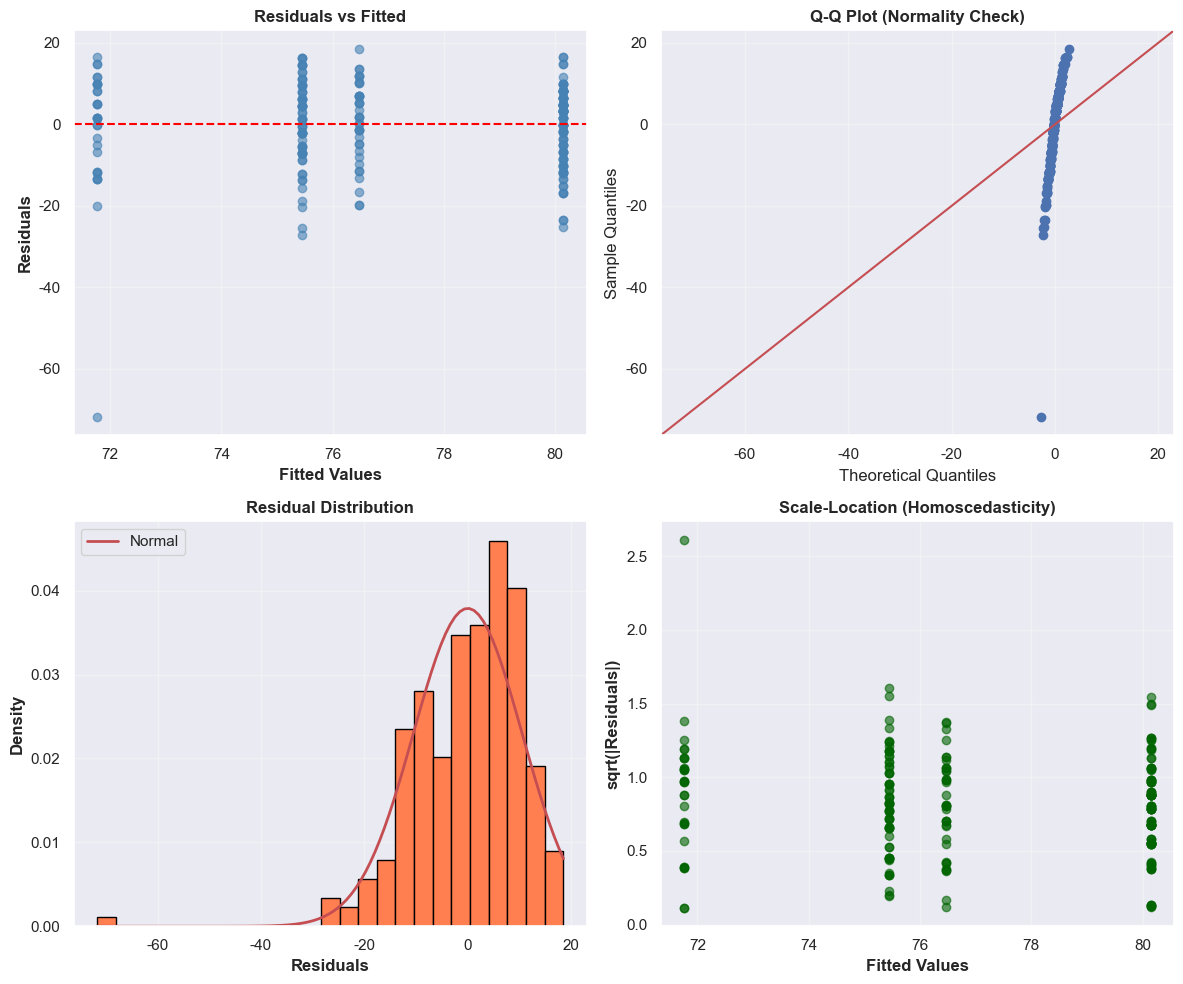

Diagnostic plots generated.


In [41]:
# Residual diagnostics

fitted = results2.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.6, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Fitted Values', fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontweight='bold')
axes[0, 0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q Plot
sm.qqplot(residuals, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histogram of Residuals
axes[1, 0].hist(residuals, bins=25, color='coral', edgecolor='black', density=True)
from scipy import stats
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Density', fontweight='bold')
axes[1, 0].set_title('Residual Distribution', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Scale-Location
std_residuals = np.sqrt(np.abs(residuals / residuals.std()))
axes[1, 1].scatter(fitted, std_residuals, alpha=0.6, color='darkgreen')
axes[1, 1].set_xlabel('Fitted Values', fontweight='bold')
axes[1, 1].set_ylabel('sqrt(|Residuals|)', fontweight='bold')
axes[1, 1].set_title('Scale-Location (Homoscedasticity)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Diagnostic plots generated.")


## 5. LLM 기반 교호작용 자동 식별

estimator에서는 LLM이 교호작용 항을 자동으로 식별한다.
OpenAI SDK의 Structured Outputs를 활용하여 이 과정을 재구현한다.

**핵심 아이디어**: 데이터셋의 변수 정보와 연구 질문을 LLM에 전달하면,
LLM이 교호작용을 탐지할 변수를 추천한다.

In [42]:
# ============================================================
# Pydantic 모델: 교호작용 식별 결과
# ============================================================

class InteractionSuggestion(BaseModel):
    """LLM이 교호작용 항의 존재 여부를 판단한 결과이다."""
    has_interaction: bool = Field(
        description="교호작용 항이 필요한지 여부"
    )
    interacting_variable: Optional[str] = Field(
        None,
        description="처치와 교호작용하는 변수명"
    )
    reasoning: str = Field(
        description="교호작용 판단 근거"
    )
    expected_direction: Optional[str] = Field(
        None,
        description="예상되는 교호작용 방향 (positive/negative/unknown)"
    )

# 데이터셋 정보 준비
columns_info = df_clean.dtypes.to_string()
sample_rows = df_clean.head(3).to_string()

# LLM에 교호작용 식별 요청
response = client.chat.completions.parse(
    model="gpt-4o-mini",
    messages=[
        {
            "role": "system",
            "content": (
                "너는 인과추론과 회귀분석 전문가이다. "
                "주어진 데이터셋에서 처치 변수와 교호작용할 가능성이 있는 "
                "변수를 식별한다. 교호작용 항은 처치 효과가 특정 하위 그룹에서 "
                "다를 때 의미가 있다."
            )
        },
        {
            "role": "user",
            "content": (
                f"다음 데이터셋에서 교호작용 항을 식별해줘.\n\n"
                f"연구 질문: 온라인 수업(format_ol)이 시험 점수(falsexam)에 미치는 효과\n"
                f"처치 변수: format_ol\n"
                f"결과 변수: falsexam\n\n"
                f"컬럼 정보:\n{columns_info}\n\n"
                f"샘플 데이터:\n{sample_rows}"
            )
        }
    ],
    response_format=InteractionSuggestion
)

# 결과 확인
suggestion = response.choices[0].message.parsed
print("=" * 60)
print("LLM 기반 교호작용 식별 결과")
print("=" * 60)
print(f"교호작용 필요: {suggestion.has_interaction}")
print(f"교호작용 변수: {suggestion.interacting_variable}")
print(f"예상 방향: {suggestion.expected_direction}")
print(f"판단 근거: {suggestion.reasoning}")

LLM 기반 교호작용 식별 결과
교호작용 필요: True
교호작용 변수: gender
예상 방향: unknown
판단 근거: 성별에 따라 온라인 수업의 효과가 다를 가능성이 있다. 예를 들어, 남성과 여성 학생들이 온라인 수업 방식에 따라 시험 점수에서 다른 결과를 보일 수 있기 때문이다.


In [43]:
# ============================================================
# LLM 제안에 따른 교호작용 모델 자동 적합
# ============================================================
# LLM이 제안한 변수로 교호작용 모델을 자동 구성한다.

if suggestion.has_interaction and suggestion.interacting_variable:
    inter_var = suggestion.interacting_variable
    print(f"LLM 제안: format_ol × {inter_var} 교호작용 모델 적합")
    print()
    
    # 교호작용 모델 구성
    formula_interaction = f"falsexam ~ C(format_ol) * {inter_var}"
    model_auto = smf.ols(formula_interaction, data=df_clean)
    results_auto = model_auto.fit()
    
    print(f"회귀식: {formula_interaction}")
    print()
    print(results_auto.summary())
else:
    print("LLM이 유의미한 교호작용을 식별하지 못했다.")
    print("기본 모델(공변량 조정만)을 사용한다.")

LLM 제안: format_ol × gender 교호작용 모델 적합

회귀식: falsexam ~ C(format_ol) * gender

                            OLS Regression Results                            
Dep. Variable:               falsexam   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     6.566
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           0.000276
Time:                        23:03:05   Log-Likelihood:                -930.89
No. Observations:                 247   AIC:                             1870.
Df Residuals:                     243   BIC:                             1884.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

## 6. 두 번째 데이터셋: ihdp_0.csv

**IHDP (Infant Health and Development Program)** 데이터는 인과추론 벤치마크 데이터셋이다.
저체중 출생아를 대상으로 한 조기 개입 프로그램의 효과를 평가한다.

- 처치: 집중 교육 프로그램 참여
- 결과: 인지 발달 점수
- 공변량: 출생 체중, 산모 나이, 산모 교육 수준 등 25개 변수

In [44]:
# ============================================================
# IHDP 데이터셋 로드 및 분석
# ============================================================
# IHDP는 인과추론 벤치마크로 널리 사용되는 데이터셋이다.
# 25개의 풍부한 공변량이 포함되어 있다.

df_ihdp = pd.read_csv('../data/all_data/ihdp_0.csv')
print("IHDP 데이터셋 로드 완료")
print(f"데이터 크기: {df_ihdp.shape}")
print(f"\n컬럼 목록: {list(df_ihdp.columns)}")
print(f"\n처음 5행:")
print(df_ihdp.head())
print(f"\n처치 변수 분포:")
print(df_ihdp['treatment'].value_counts())

IHDP 데이터셋 로드 완료
데이터 크기: (747, 27)

컬럼 목록: ['treatment', 'y', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25']

처음 5행:
   treatment         y        x1        x2        x3        x4        x5  \
0          1  5.599916 -0.528603 -0.343455  1.128554  0.161703 -0.316603   
1          0  6.875856 -1.736945 -1.802002  0.383828  2.244320 -0.629189   
2          0  2.996273 -0.807451 -0.202946 -0.360898 -0.879606  0.808706   
3          0  1.366206  0.390083  0.596582 -1.850350 -0.879606 -0.004017   
4          0  1.963538 -1.045229 -0.602710  0.011465  0.161703  0.683672   

         x6  x7  x8  ...  x16  x17  x18  x19  x20  x21  x22  x23  x24  x25  
0  1.295216   1   0  ...    1    1    1    1    0    0    0    0    0    0  
1  1.295216   0   0  ...    1    1    1    1    0    0    0    0    0    0  
2 -0.526556   0   0  ...    1    0    1    1    0    0    0    0    0    0  


In [45]:
# ============================================================
# IHDP: 공변량 조정 전후 비교
# ============================================================
# 다양한 공변량을 활용한 OLS 회귀 분석

# 결과 변수와 처치 변수 확인
outcome_col = 'y'
treatment_col = 'treatment'

# 수치형 공변량 선택 (x1 ~ x25)
covariate_cols = [c for c in df_ihdp.columns
                  if c.startswith('x') and c[1:].isdigit()]
print(f"사용할 공변량 ({len(covariate_cols)}개): {covariate_cols[:10]}...")

# 모델 A: 공변량 없음
formula_a = f"{outcome_col} ~ {treatment_col}"
results_a = smf.ols(formula_a, data=df_ihdp).fit()

# 모델 B: 주요 공변량 5개
top5_covs = covariate_cols[:5]
formula_b = f"{outcome_col} ~ {treatment_col} + {' + '.join(top5_covs)}"
results_b = smf.ols(formula_b, data=df_ihdp).fit()

# 모델 C: 전체 공변량
formula_c = f"{outcome_col} ~ {treatment_col} + {' + '.join(covariate_cols)}"
results_c = smf.ols(formula_c, data=df_ihdp).fit()

# 결과 비교
print("\n" + "=" * 70)
print("IHDP 데이터: 공변량 조정 비교")
print("=" * 70)
print(f"{'모델':<25} {'처치효과':>10} {'SE':>10} {'p-value':>10} {'R²':>8}")
print("-" * 70)
print(f"{'A: 공변량 없음':<25} {results_a.params[treatment_col]:>10.4f} "
      f"{results_a.bse[treatment_col]:>10.4f} "
      f"{results_a.pvalues[treatment_col]:>10.4f} "
      f"{results_a.rsquared:>8.4f}")
print(f"{'B: 공변량 5개':<25} {results_b.params[treatment_col]:>10.4f} "
      f"{results_b.bse[treatment_col]:>10.4f} "
      f"{results_b.pvalues[treatment_col]:>10.4f} "
      f"{results_b.rsquared:>8.4f}")
print(f"{'C: 전체 공변량':<25} {results_c.params[treatment_col]:>10.4f} "
      f"{results_c.bse[treatment_col]:>10.4f} "
      f"{results_c.pvalues[treatment_col]:>10.4f} "
      f"{results_c.rsquared:>8.4f}")
print("\n→ 공변량이 추가될수록 R²가 증가하고 표준오차가 감소한다.")

사용할 공변량 (25개): ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']...

IHDP 데이터: 공변량 조정 비교
모델                              처치효과         SE    p-value       R²
----------------------------------------------------------------------
A: 공변량 없음                     4.0211     0.1427     0.0000   0.5160
B: 공변량 5개                     4.1373     0.1394     0.0000   0.5550
C: 전체 공변량                     3.9287     0.1128     0.0000   0.7402

→ 공변량이 추가될수록 R²가 증가하고 표준오차가 감소한다.
